In [1]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
import matplotlib as mpl
from helpers.simulation import *
from helpers.qtransform import *
from helpers.config import *

from scipy.stats import truncnorm
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/gwaves_lisa_py311/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
gw_dict = {}
with h5py.File(gw_dataset_path, 'r') as h5:
    for key in list(h5.keys()):
        gw_dict[key] = h5[key][:]

In [74]:
i = 71
tdi_dict = make_tdi_dict(gw_dict['X'][i],\
                            gw_dict['Y'][i], gw_dict['Z'][i], whiten=True)

event = 5*3600
t_axis, f_axis, QT = generate_qscan(tdi_dict, 'A', PIPE, event, resolution=256,
                                frange=(1e-4, 1e-1), trange=(-3, 3), Q=6)

QTnorm = QT/np.max(QT)
len(QTnorm[QTnorm > 0.5])

344

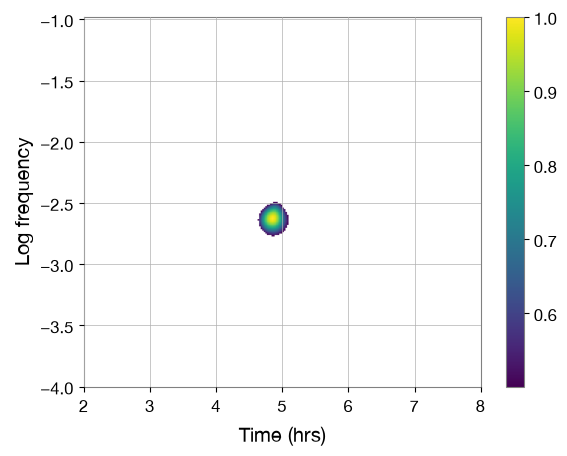

In [75]:
QTnorm = QT/np.max(QT)
QTnorm[QTnorm <= 0.5] = np.nan

plt.imshow(QTnorm, extent=[t_axis[0]/3600, t_axis[-1]/3600, np.log10(f_axis[0]), np.log10(f_axis[-1])],\
     aspect='auto', origin='lower')
#plt.title(f'Amp = {amp:.2g} m/s^2, Beta = {beta:.2g} secs,\n Inj_point: {inj_point}, t_inj: {tevent/3600} hrs', fontsize=12)
plt.colorbar()

#plt.clim(0, 5)
plt.ylabel('Log frequency')
plt.xlabel('Time (hrs)')
plt.show()

In [44]:
data = np.load(GW_DATASETS / 'optimum_q.npz')
idx = data['index']
qbest = data['Qopt']

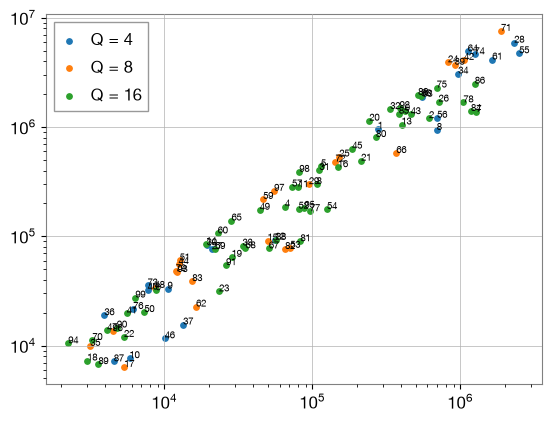

In [45]:
for q in np.unique(qbest):
    mask = (qbest == q)

    plt.scatter(
        gw_dict['m1'][mask],
        gw_dict['m2'][mask],
        s=15,
        label=f'Q = {q}'
    )

    for x, y, i in zip(gw_dict['m1'][mask],
                       gw_dict['m2'][mask],
                       idx[mask]):
        plt.text(x, y, str(i), fontsize=7)

plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()